# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyen Quoc Viet"  # TODO: Họ và tên
STUDENT_ID = "2453415"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyen Quoc Viet (2453415)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\HP\Desktop\MLIOT\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...
row_max = np.max(logits, axis=1, keepdims=True)

shifted_logits = logits - row_max

exp_logits = np.exp(shifted_logits)

# Tổng exp trên mỗi hàng
sum_exp = np.sum(exp_logits, axis=1, keepdims=True)
class_probabilities = exp_logits / sum_exp

predicted_classes = np.argmax(class_probabilities, axis=1)

confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std

X_val_scaled = (X_val - train_feature_mean) / train_feature_std


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...
correct_mask = (predicted_classes == true_labels)

high_confidence_mask = (confidence_scores >= confidence_threshold)


review_mask = ~(correct_mask & high_confidence_mask)

review_indices = np.where(review_mask)[0]
required = ["correct_mask", "high_confidence_mask", "review_mask", "review_indices"]
if not all(name in globals() for name in required):
    print("Complete N3 to run this self-check.")
else:
    assert review_mask.dtype == bool
    assert np.all(review_mask == ((predicted_classes != true_labels) | (confidence_scores < confidence_threshold)))
    assert np.all(review_indices == np.where(review_mask)[0])
    print("N3 self-check passed")
    print(f"Các mẫu cần kiểm tra lại (indices): {review_indices}")


N3 self-check passed
Các mẫu cần kiểm tra lại (indices): [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = np.flip(normalized_batch, axis=2).copy()

augmented_batch[0, 0, 0, 0] = 1.0

required = ["normalized_batch", "augmented_batch"]
if not all(name in globals() for name in required):
    print("Complete N4 to run this self-check.")
else:
    assert normalized_batch[0, 0, 0, 0] != 1.0, "Bộ nhớ chưa độc lập!"
    assert normalized_batch.dtype == np.float32
    assert normalized_batch.max() <= 1.0
    assert augmented_batch.shape == normalized_batch.shape
    print("N4 self-check passed")

N4 self-check passed


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

## 1. Đối tượng đại diện của mỗi dòng (Row Representation)
Mỗi dòng trong tập dữ liệu đại diện cho một **mẫu xe ô tô cụ thể** (*an automobile*). Thông tin của mỗi xe bao gồm các nhóm thuộc tính sau:

*   **Đặc điểm kỹ thuật:** Kích thước, loại động cơ, công suất (`horsepower`),...
*   **Thông tin thương hiệu:** Hãng xe (`make`) và kiểu dáng (`body_style`).
*   **Chỉ số kinh tế:** Mức tiêu hao nhiên liệu (`city_mpg`), giá bán (`price`).
*   **Chỉ số bảo hiểm:** Mức độ rủi ro (`symboling`), tổn thất định mức (`normalized_losses`).

---

## 2. Ký hiệu giá trị thiếu (Missing Value Notation)
Dựa vào cột `normalized_losses` ở các dòng đầu tiên, ký hiệu giá trị thiếu trong file CSV này là **dấu chấm hỏi `?`**.


---

## 3. Ý nghĩa của chỉ số `symboling`
`symboling` là **chỉ số đánh giá mức độ rủi ro bảo hiểm** (*Insurance risk rating*) được gán cho mỗi chiếc xe khi mới xuất xưởng. 

###  Thang đo và Quy luật giá trị:

| Giá trị | Mức độ rủi ro | Đặc điểm thường gặp |
| :---: | :--- | :--- |
| **Số dương (+2, +3)** |  **Cao** | Xe thể thao, xe đắt tiền, tỷ lệ tai nạn cao hoặc chi phí sửa chữa lớn. |
| **Số 0** |  **Trung bình** | Các dòng xe phổ thông, gia đình tiêu chuẩn. |
| **Số âm (-1, -2)** |  **Thấp (An toàn)** | Xe có độ an toàn cao, thiết kế bền bỉ, ít rủi ro về mặt bảo hiểm. |

---


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [33]:
raw_df = pd.read_csv('data/automobile_raw.csv')

raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

print(f"Kích thước dữ liệu: {raw_shape}")
print(f"Tổng số dấu '?' tìm thấy: {raw_missing_marker_count} \n")

print("Kiểu dữ liệu của các cột:")
dtypes_df = raw_df.dtypes.to_frame(name='Data Type')
display(dtypes_df)

print("\n5 dòng đầu tiên của dữ liệu:")
display(raw_df.head())

Kích thước dữ liệu: (205, 26)
Tổng số dấu '?' tìm thấy: 59 

Kiểu dữ liệu của các cột:


,Data Type
symboling,int64
normalized_losses,object
make,object
fuel_type,object
aspiration,object
num_doors,object
body_style,object
drive_wheels,object
engine_location,object
wheel_base,float64



5 dòng đầu tiên của dữ liệu:


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [22]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [23]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
df_clean = raw_df.replace('?', np.nan)

# 2. Chuyển đổi các cột sang kiểu số
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')


missing_series = df_clean.isnull().sum()
missing_by_column = missing_series[missing_series > 0]

# Chuyển thành DataFrame để hiển thị bảng đẹp mắt bằng display()
missing_df = missing_by_column.to_frame(name='Missing Count')

print("Báo cáo các cột có giá trị thiếu:")
display(missing_df)

Báo cáo các cột có giá trị thiếu:


,Missing Count
normalized_losses,41
num_doors,2
bore,4
stroke,4
horsepower,2
peak_rpm,2
price,4


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
## PHÂN TÍCH VÀ XỬ LÝ GIÁ TRỊ THIẾU (MISSING VALUES)


## 1. Lý do không điền một giá trị duy nhất cho tất cả cột số (Numeric Columns)

*   **Sai lệch bản chất và thang đo:** Mỗi cột đại diện cho một đại lượng vật lý với phạm vi giá trị hoàn toàn khác nhau. 
    *   *Ví dụ:* `wheel_base` (chiều dài cơ sở) có khoảng giá trị từ $90 - 120$, trong khi `compression_ratio` (tỉ số nén) chỉ dao động từ $8 - 10$. Việc dùng chung một giá trị sẽ làm mất đi ý nghĩa thực tế của biến số.
*   **Gây nhiễu cho mô hình thống kê:** Điền một số cố định (ví dụ: số `0`) vào tất cả các cột dữ liệu thiếu sẽ làm kéo tụt giá trị trung bình (`mean`) và làm biến đổi độ lệch chuẩn (`std`). Điều này trực tiếp làm sai lệch kết quả phân tích thống kê và các mô hình học máy sau này.

---

## 2. Phương pháp xử lý giá trị thiếu đối với biến `price`

###  Lựa chọn: Drop (Xóa bỏ các dòng thiếu giá trị `price`)

###  Lý do chi tiết:
*   **Bản chất của biến mục tiêu:** Trong bài toán phân tích dữ liệu ô tô (EDA), `price` đóng vai trò là biến mục tiêu quan trọng nhất nhằm xác định các yếu tố ảnh hưởng đến giá xe.
*   **Tránh sai lệch mối quan hệ:** Việc tự ý bù đắp giá trị thiếu cho `price` (như điền bằng giá trị trung bình) sẽ làm giảm tính chính xác của mối tương quan giữa các đặc điểm kỹ thuật và giá trị thực tế của xe. Xóa bỏ các dòng thiếu giúp giữ cho tập dữ liệu còn lại khách quan và đáng tin cậy hơn.

---

## 3. Ảnh hưởng từ việc thiếu dữ liệu diện rộng ở cột `normalized_losses`

Cột `normalized_losses` có tỷ lệ khuyết thiếu cao (khoảng 20%), dẫn đến hai hệ lụy lớn sau:

*   **Mất mát thông tin diện rộng (nếu dùng Drop):** Nếu áp dụng phương pháp xóa dòng cho cột này, một lượng lớn mẫu dữ liệu quý giá (lên tới 1/5 tập dữ liệu) của các cột thông tin khác cũng sẽ bị xóa bỏ theo.
*   **Độ tin cậy thấp (nếu dùng Fill):** Nếu áp dụng phương pháp điền giá trị thay thế (imputation), do số lượng mẫu bị thiếu quá lớn nên giá trị đại diện được chọn (như `mean` hoặc `median`) có sai số cao, không phản ánh đúng thực tế rủi ro tổn thất bảo hiểm của từng dòng xe.

---


## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [24]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [34]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.values.astype(np.float64)

auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)

epsilon = 1e-8
X_auto_scaled = (X_auto - auto_feature_mean) / (auto_feature_std + epsilon)

stats_df = pd.DataFrame({
    'Mean': X_auto_scaled.mean(axis=0).round(2),
    'Std': X_auto_scaled.std(axis=0).round(2)
}, index=AUTO_FEATURES)

print(f"Số lượng mẫu sau khi lọc: {len(X_auto)}")
print(f"Shape của ma trận chuẩn hóa: {X_auto_scaled.shape}")
print("Thông số sau chuẩn hóa:")
display(stats_df)

Số lượng mẫu sau khi lọc: 199
Shape của ma trận chuẩn hóa: (199, 6)
Thông số sau chuẩn hóa:


,Mean,Std
curb_weight,0.0,1.0
engine_size,0.0,1.0
horsepower,0.0,1.0
city_mpg,0.0,1.0
highway_mpg,0.0,1.0
price,-0.0,1.0


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [ ]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...
price_index = AUTO_FEATURES.index('price')


price_z = (X_auto[:, price_index] - auto_feature_mean[price_index]) / auto_feature_std[price_index]

price_outlier_mask = np.abs(price_z) > 2

price_outliers = analysis_df[price_outlier_mask]

print(f"Số lượng xe bị coi là outlier về giá: {len(price_outliers)}")
print("\nDanh sách các xe có giá ngoại lệ:")
display(price_outliers)

Số lượng xe bị coi là outlier về giá: 14

Danh sách các xe có giá 'ngoại lệ':


,curb_weight,engine_size,horsepower,city_mpg,highway_mpg,price
15,3230,209,182.0,16,22,30760.0
16,3380,209,182.0,16,22,41315.0
17,3505,209,182.0,15,20,36880.0
47,4066,258,176.0,15,19,32250.0
48,4066,258,176.0,15,19,35550.0
49,3950,326,262.0,13,17,36000.0
70,3770,183,123.0,22,25,31600.0
71,3740,234,155.0,16,18,34184.0
72,3685,234,155.0,16,18,35056.0
73,3900,308,184.0,14,16,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [32]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...
engine_size_col = X_auto[:, 1]
price_col = X_auto[:, 5]

corr_matrix = np.corrcoef(engine_size_col, price_col)
engine_price_corr = corr_matrix[0, 1]


price_by_body_style_df = df_clean.groupby('body_style')['price'].mean().reset_index()

price_by_body_style_df.columns = ['Body Style', 'Average Price']

price_by_body_style_df = price_by_body_style_df.sort_values(by='Average Price', ascending=False)

print("Giá trung bình theo từng kiểu dáng xe:")
display(price_by_body_style_df)


Giá trung bình theo từng kiểu dáng xe:


,Body Style,Average Price
1,hardtop,22208.500000
0,convertible,21890.500000
3,sedan,14459.755319
4,wagon,12371.960000
2,hatchback,9957.441176


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

## M2.1 Price phân phối như thế nào?

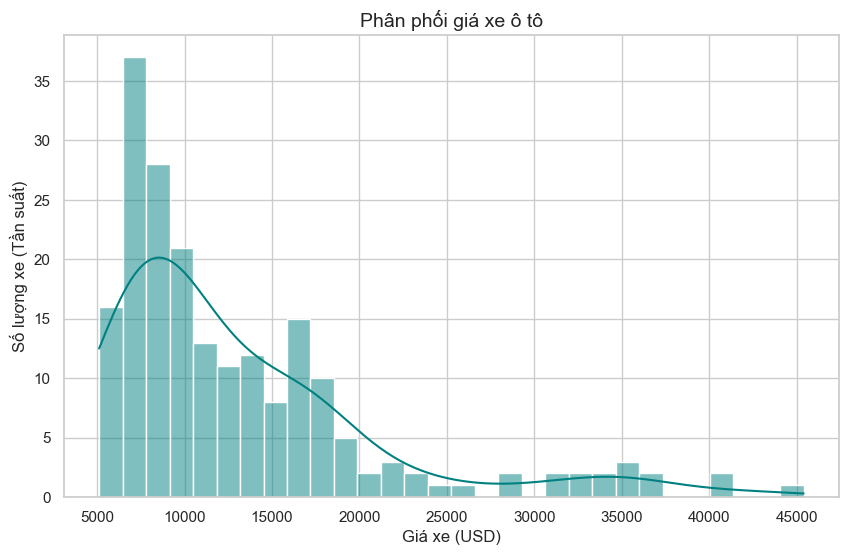

In [36]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], kde=True, color='teal', bins=30)

plt.title("Phân phối giá xe ô tô", fontsize=14)
plt.xlabel("Giá xe (USD)", fontsize=12)
plt.ylabel("Số lượng xe (Tần suất)", fontsize=12)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
*   **Hình dáng phân phối:** Đồ thị phân phối giá xe bị **lệch phải (Right-skewed)** một cách rõ rệt.
*   **Phân khúc phổ thông:** Phần lớn các dòng xe trong tập dữ liệu tập trung chủ yếu ở phân khúc giá rẻ và bình dân, dao động trong khoảng từ **$5,000$ đến $15,000$ USD**.
*   **Phân khúc cao cấp (Outliers):** Xuất hiện một số ít dòng xe hạng sang có mức giá vượt trội hẳn lên (**trên $30,000$ USD**). Nhóm xe này kéo dài đồ thị về phía bên phải, tạo thành hiện tượng "đuôi dài" (long tail) trong phân phối thống kê.


## M2.2 Dataset có cân bằng theo body style không?

C:\Users\HP\AppData\Local\Temp\ipykernel_19552\2012459041.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='body_style', data=df_clean, order=style_order, palette='viridis')


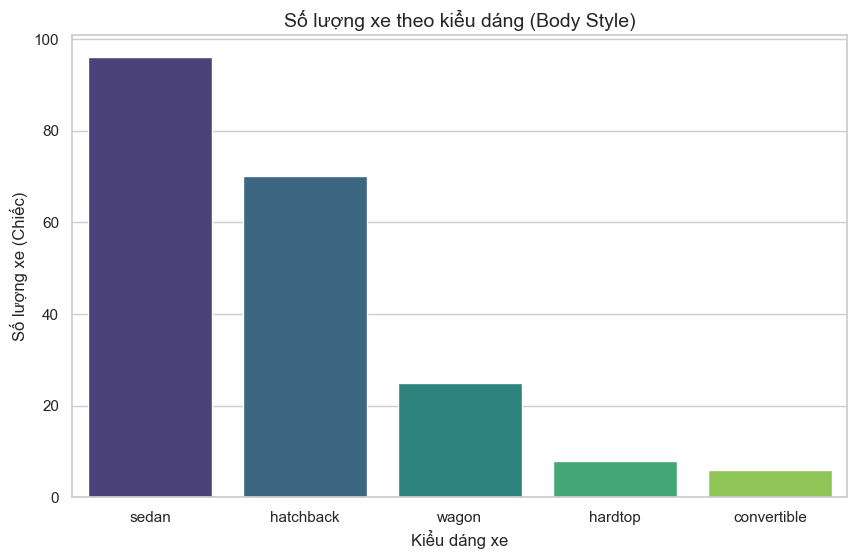

In [37]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(10, 6))
style_order = df_clean['body_style'].value_counts().index

sns.countplot(x='body_style', data=df_clean, order=style_order, palette='viridis')

plt.title("Số lượng xe theo kiểu dáng (Body Style)", fontsize=14)
plt.xlabel("Kiểu dáng xe", fontsize=12)
plt.ylabel("Số lượng xe (Chiếc)", fontsize=12)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
*   **Mất cân bằng dữ liệu (Data Imbalance):** `Sedan` và `Hatchback` là hai kiểu dáng chiếm tỷ trọng áp đảo, xuất hiện phổ biến nhất trong danh sách dữ liệu.
*   **Phân khúc đặc thù:** Các dòng xe như `Convertible` (mui trần) và `Hardtop` có số lượng mẫu rất hạn chế. Điều này phản ánh chính xác thực tế thị trường khi đây là những dòng xe kén người dùng và có tệp khách hàng hẹp.


## M2.3 Price khác nhau theo body style ra sao?

C:\Users\HP\AppData\Local\Temp\ipykernel_19552\3783443120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body_style', y='price', data=df_clean, palette='Set3')


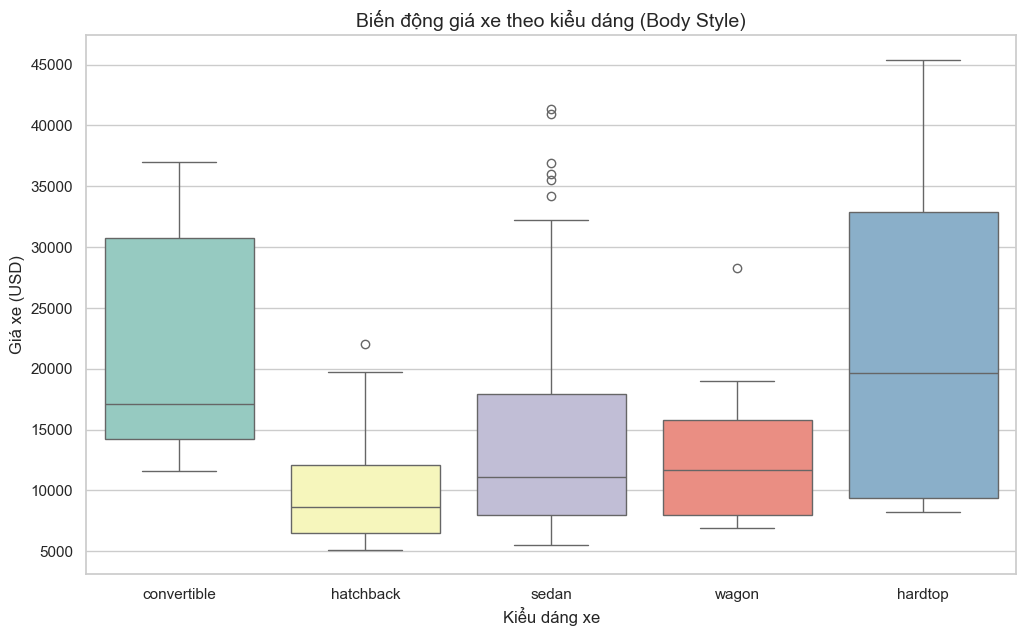

In [38]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(12, 7))
sns.boxplot(x='body_style', y='price', data=df_clean, palette='Set3')

plt.title("Biến động giá xe theo kiểu dáng (Body Style)", fontsize=14)
plt.xlabel("Kiểu dáng xe", fontsize=12)
plt.ylabel("Giá xe (USD)", fontsize=12)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
*   **Phân khúc cao cấp:** Các dòng xe `Hardtop` và `Convertible` sở hữu mức giá trung vị (đường gạch giữa hộp - *median*) cao nhất, đồng thời có dải giá rộng. Điều này xác vị trí của hai kiểu dáng này thuộc phân khúc xe hạng sang.
*   **Phân khúc phổ thông và đa dạng:** 
    *   `Hatchback` là dòng xe có phân khúc giá thấp nhất và biên độ dao động ổn định nhất.
    *   `Sedan` hiển thị rất nhiều điểm ngoại lệ (`outliers`) tập trung ở vùng giá cao. Điều này chứng minh dòng xe `Sedan` có dải sản phẩm trải dài toàn diện từ phân khúc bình dân đến hạng sang.


## M2.4 Engine size liên quan thế nào tới price?

In [ ]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(11, 7))
sns.scatterplot(x='engine_size', y='price', hue='fuel_type', data=df_clean, s=80, alpha=0.7)

plt.title("Mối quan hệ giữa Kích thước động cơ và Giá xe", fontsize=14)
plt.xlabel("Kích thước động cơ (Cubic Inches)", fontsize=12)
plt.ylabel("Giá xe (USD)", fontsize=12)
plt.legend(title="Loại nhiên liệu")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

*   **Tương quan thuận mạnh mẽ:** Xuất hiện xu hướng tuyến tính rõ rệt giữa kích thước động cơ và giá xe. Khi `engine_size` tăng lên, `price` của phương tiện cũng tăng theo tỷ lệ thuận.
*   **Phân bố theo loại nhiên liệu:** 
    *   Hệ thống động cơ chạy xăng (`gas`) chiếm số lượng áp đảo trong toàn bộ tập dữ liệu và trải dài trên nhiều phân khúc giá.
    *   Hệ thống động cơ chạy dầu (`diesel`) chủ yếu tập trung ở nhóm có cấu hình động cơ vừa và nhỏ, đi kèm với mức giá cạnh tranh trên thị trường.


## M2.5 Các feature numeric tương quan ra sao?

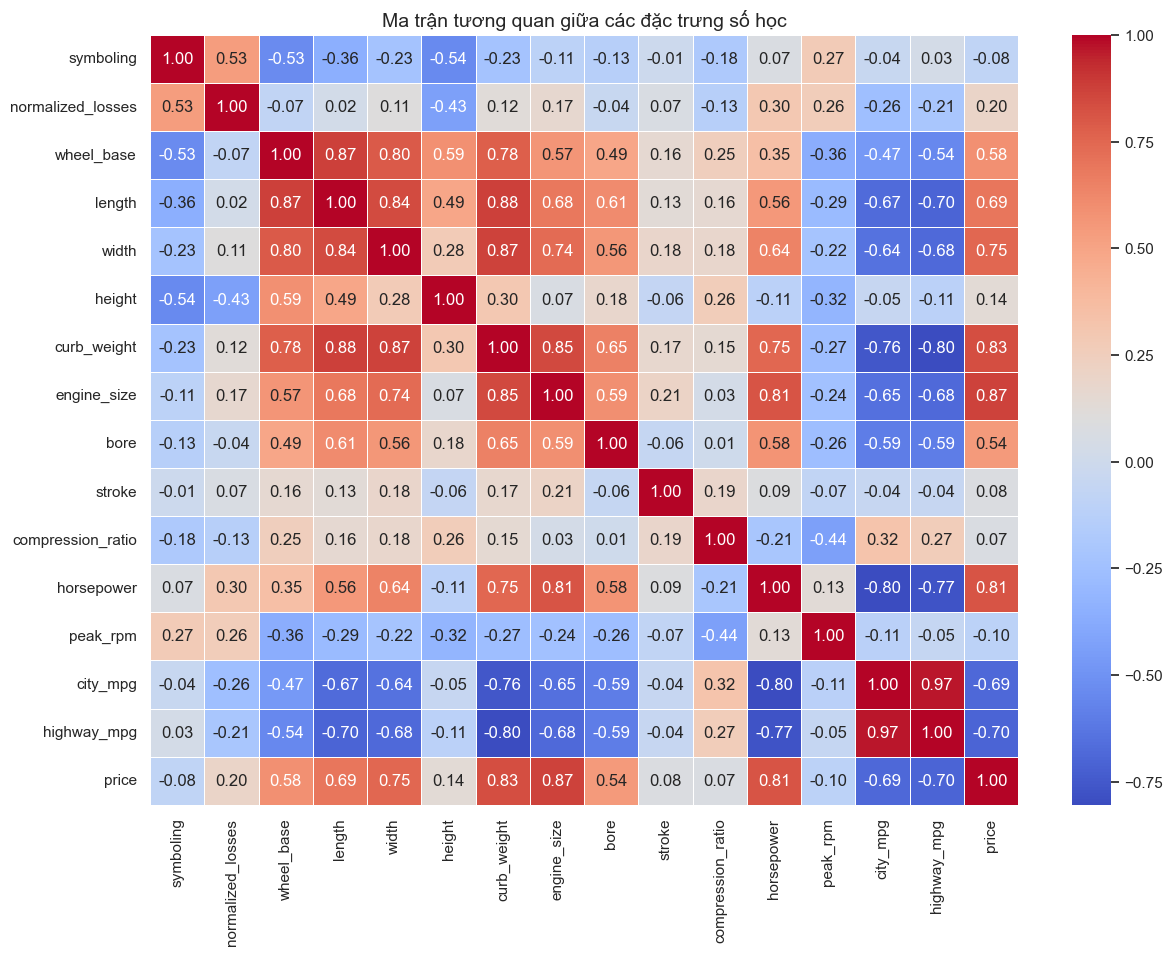

In [39]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df_clean[NUMERIC_COLUMNS].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Ma trận tương quan giữa các đặc trưng số học", fontsize=14)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
*   **Tương quan thuận mạnh mẽ (Positive Correlation):** Biến `price` có mối tương quan tuyến tính thuận rất chặt chẽ với các đặc tính kỹ thuật sau:
    *   `engine_size` (kích thước động cơ): **$0.87$**
    *   `curb_weight` (trọng lượng không tải): **$0.83$**
    *   `horsepower` (mã lực): **$0.81$**
    *   *Hệ quả:* Những dòng xe có trọng lượng càng lớn, động cơ càng mạnh thì giá thành sản phẩm càng cao.
*   **Tương quan nghịch rõ rệt (Negative Correlation):** Biến `price` tỷ lệ nghịch với hiệu suất sử dụng nhiên liệu:
    *   `highway_mpg` (mức tiêu hao nhiên liệu trên đường trường): **$-0.70$**
    *   `city_mpg` (mức tiêu hao nhiên liệu trong đô thị): **$-0.69$**
    *   *Hệ quả:* Các dòng xe thuộc phân khúc cao cấp (trọng lượng nặng, hiệu suất máy cao) có xu hướng tiêu thụ nhiều nhiên liệu hơn, dẫn đến số dặm đi được trên một đơn vị gallon (`mpg`) thấp hơn đáng kể.


## M2.6 Biểu đồ tự chọn

Đâu là những thương hiệu xe sang chiếm lĩnh phân khúc cao nhất về giá trong bộ dữ liệu này?

C:\Users\HP\AppData\Local\Temp\ipykernel_19552\1402303671.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_expensive.values, y=top_10_expensive.index, palette='magma')


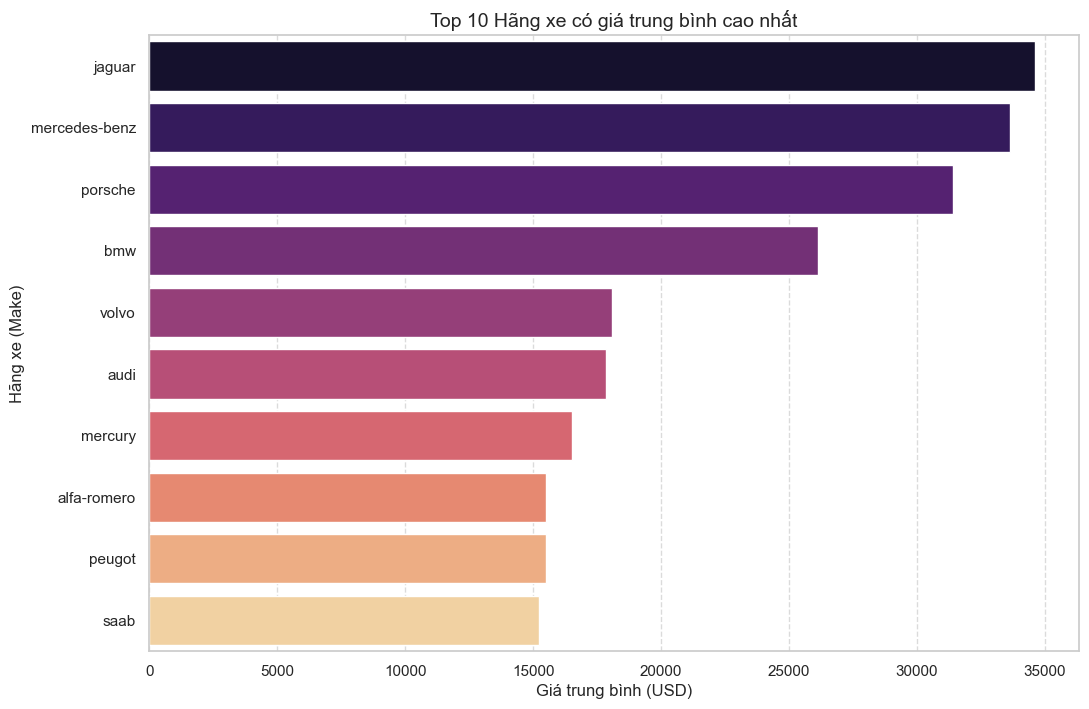

In [40]:
# TODO M2.6: biểu đồ thanh ngang (Horizontal Bar Plot) cho Top 10 hãng xe theo giá trung bình
plt.figure(figsize=(12, 8))

# Tính giá trung bình theo hãng, lấy top 10 hãng cao nhất
top_10_expensive = df_clean.groupby('make')['price'].mean().sort_values(ascending=False).head(10)

# Vẽ biểu đồ thanh ngang
sns.barplot(x=top_10_expensive.values, y=top_10_expensive.index, palette='magma')

plt.title("Top 10 Hãng xe có giá trung bình cao nhất", fontsize=14)
plt.xlabel("Giá trung bình (USD)", fontsize=12)
plt.ylabel("Hãng xe (Make)", fontsize=12)

# Thêm lưới dọc để dễ so sánh giá trị
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
*   **Phân khúc siêu sang thống trị:** `Jaguar`, `Mercedes-Benz` và `Porsche` là ba thương hiệu dẫn đầu thị trường về mức giá trung bình. Giá trị của các dòng xe thuộc những hãng này vượt trội hoàn toàn so với phần còn lại, đạt ngưỡng **trên $30,000$ USD**.
*   **Tính bao quát của tập dữ liệu:** Kết quả thống kê xác nhận tập dữ liệu có độ bao phủ rộng, trải dài từ các dòng xe thương mại phổ thông cho đến các phân khúc thương hiệu hạng sang. Đây là nguyên nhân trực tiếp giải thích cho sự xuất hiện của các điểm ngoại lệ (`outliers`) về giá đã được ghi nhận trong các biểu đồ phân tích trước đó.


# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
## 1. Phát hiện chính

*   **Máy mạnh thì giá cao:** Kích thước động cơ (`engine_size`) và giá xe (`price`) tỷ lệ thuận rất mạnh với nhau ($0.87$). Động cơ là yếu tố chính quyết định giá xe.
*   **Xe đắt tiền tốn xăng:** Xe càng đắt tiền thường có hiệu suất cao nên hao xăng hơn. Giá xe tỷ lệ nghịch với số dặm đi được trong phố (`city_mpg`) ở mức $-0.69$.
*   **Thị trường chủ yếu là xe giá rẻ:** Đa số xe trong bộ dữ liệu có giá dưới $15,000$ USD. Số ít xe sang trên $30,000$ USD tập trung vào hãng `Jaguar`, `Porsche` và `Mercedes-Benz`.
*   **Dáng xe quyết định phân khúc:** Xe mui trần `Convertible` và `Hardtop` có giá trung bình cao nhất. Xe `Hatchback` có giá rẻ nhất, phù hợp với người dân.

---

## 2. Hạn chế của dữ liệu

*   **Thiếu nhiều dữ liệu:** Nhiều cột bị trống ký hiệu là `?`. Cột rủi ro bảo hiểm (`normalized_losses`) thiếu hơn 20%, nếu tự điền số trung bình vào sẽ dễ bị sai lệch.
*   **Không có năm sản xuất:** Dữ liệu không ghi rõ xe làm ra năm nào. Giá xe và công nghệ tiết kiệm xăng thay đổi rất nhanh, nên các kết luận này có thể đã lỗi thời với xe đời mới.

---

## 3. Tương quan không phải là Nhân quả

*   **Thực tế:** Xe có chiều dài cơ sở (`wheel_base`) càng dài thì giá càng cao.
*   **Giải thích:** Không phải cứ kéo dài thân xe là xe tự đắt lên. Thân xe dài là đặc điểm của xe hạng sang. Chính nội thất cao cấp và động cơ mạnh của xe sang mới làm giá tăng lên, chứ không phải do chiều dài.

---

## 4. Câu hỏi nghiên cứu tiếp theo

*   "Nên dùng những đặc tính kỹ thuật nào để xây dựng mô hình máy học dự đoán chính xác nhất giá của một chiếc xe mới?"
